# Chapter 12 Solutions: HHL Algorithm

---

**📘 INSTRUCTOR NOTE:**
- Solutions use the same utilities as the main textbook notebooks
- Students should work through the main chapter notebook first
- Some solutions may still be in development (marked as WIP)

---


In [ ]:
# Solutions Setup
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

import numpy as np
import scipy.linalg

# Add utilities to path
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

from Chapter12_HHL_functions import myHHL

print('Solutions setup complete!')

Solutions setup complete!


In [ ]:


def estimate_lambda_bounds_gershgorin(A, verbose=True):
    """
    Estimate eigenvalue bounds using Gershgorin Circle Theorem.
    
    Gershgorin's Theorem: Every eigenvalue of A lies within at least one 
    Gershgorin disc D_i = {z : |z - A_ii| ≤ R_i} where R_i = Σ_{j≠i} |A_ij|
    
    Parameters:
    -----------
    A : numpy.ndarray
        Square matrix (N x N)
    verbose : bool
        If True, print detailed information
    
    Returns:
    --------
    lambda_lower : float
        Lower bound on minimum eigenvalue
    lambda_upper : float
        Upper bound on maximum eigenvalue
    disc_info : dict
        Information about Gershgorin discs for each row
    """
    if A.shape[0] != A.shape[1]:
        raise ValueError("Matrix must be square")
    
    n = A.shape[0]
    lambda_upper_bound = -np.inf
    lambda_lower_bound = np.inf
    
    disc_info = {
        'centers': [],
        'radii': [],
        'lower_bounds': [],
        'upper_bounds': []
    }
    
    # Row-wise Gershgorin discs
    if verbose:
        print("=" * 70)
        print("GERSHGORIN CIRCLE THEOREM - ROW-WISE ANALYSIS")
        print("=" * 70)
        print(f"{'Row':<6} {'Center':<12} {'Radius':<12} {'Lower':<12} {'Upper':<12}")
        print("-" * 70)
    
    for i in range(n):
        center = A[i, i]
        radius = np.sum(np.abs(A[i, :])) - np.abs(A[i, i])
        disc_lower = center - radius
        disc_upper = center + radius
        
        disc_info['centers'].append(center)
        disc_info['radii'].append(radius)
        disc_info['lower_bounds'].append(disc_lower)
        disc_info['upper_bounds'].append(disc_upper)
        
        lambda_upper_bound = max(lambda_upper_bound, disc_upper)
        lambda_lower_bound = min(lambda_lower_bound, disc_lower)
        
        if verbose:
            print(f"{i:<6} {center:>11.6f} {radius:>11.6f} {disc_lower:>11.6f} {disc_upper:>11.6f}")
    
    # For symmetric matrices, can also use column-wise (should give same result)
    # But for numerical stability, check both
    is_symmetric = np.allclose(A, A.T)
    
    if is_symmetric and verbose:
        print("\nMatrix is symmetric - row and column discs coincide")
    
    # If lower bound is non-positive but we expect positive definite matrix
    if lambda_lower_bound <= 0:
        if verbose:
            print(f"\nWarning: Row-wise lower bound = {lambda_lower_bound:.6f} ≤ 0")
            print("Checking column-wise Gershgorin discs...")
        
        # Try column-wise
        lambda_lower_bound_col = np.inf
        for j in range(n):
            center = A[j, j]
            radius = np.sum(np.abs(A[:, j])) - np.abs(A[j, j])
            disc_lower = center - radius
            lambda_lower_bound_col = min(lambda_lower_bound_col, disc_lower)
        
        if verbose:
            print(f"Column-wise lower bound = {lambda_lower_bound_col:.6f}")
        
        lambda_lower_bound = max(lambda_lower_bound, lambda_lower_bound_col)
    
    if verbose:
        print("=" * 70)
        print(f"BOUNDS: λ_min ≥ {lambda_lower_bound:.6f}, λ_max ≤ {lambda_upper_bound:.6f}")
        print("=" * 70)
    
    return lambda_lower_bound, lambda_upper_bound, disc_info


def compare_with_exact(A, lambda_lower_bound, lambda_upper_bound):
    """
    Compare Gershgorin bounds with exact eigenvalues.
    
    Parameters:
    -----------
    A : numpy.ndarray
        Matrix
    lambda_lower_bound : float
        Gershgorin lower bound
    lambda_upper_bound : float
        Gershgorin upper bound
    """
    # Compute exact eigenvalues
    eigenvalues = scipy.linalg.eigvalsh(A)  # For symmetric/Hermitian matrices
    lambda_min_exact = np.min(eigenvalues)
    lambda_max_exact = np.max(eigenvalues)
    
    print("\n" + "=" * 70)
    print("COMPARISON WITH EXACT EIGENVALUES")
    print("=" * 70)
    print(f"{'Quantity':<30} {'Gershgorin':<20} {'Exact':<20}")
    print("-" * 70)
    print(f"{'Minimum eigenvalue':<30} {lambda_lower_bound:>19.6f} {lambda_min_exact:>19.6f}")
    print(f"{'Maximum eigenvalue':<30} {lambda_upper_bound:>19.6f} {lambda_max_exact:>19.6f}")
    print("-" * 70)
    
    # Check if bounds are valid
    if lambda_lower_bound <= lambda_min_exact:
        print(f"✓ Lower bound valid: {lambda_lower_bound:.6f} ≤ {lambda_min_exact:.6f}")
    else:
        print(f"✗ Lower bound INVALID: {lambda_lower_bound:.6f} > {lambda_min_exact:.6f}")
    
    if lambda_upper_bound >= lambda_max_exact:
        print(f"✓ Upper bound valid: {lambda_upper_bound:.6f} ≥ {lambda_max_exact:.6f}")
    else:
        print(f"✗ Upper bound INVALID: {lambda_upper_bound:.6f} < {lambda_max_exact:.6f}")
    
    # Tightness metrics
    lower_gap = lambda_min_exact - lambda_lower_bound
    upper_gap = lambda_upper_bound - lambda_max_exact
    
    print("-" * 70)
    print(f"Lower bound gap: {lower_gap:.6f} ({100*lower_gap/lambda_min_exact:.2f}% of λ_min)")
    print(f"Upper bound gap: {upper_gap:.6f} ({100*upper_gap/lambda_max_exact:.2f}% of λ_max)")
    print("=" * 70)
    
    return eigenvalues


def visualize_gershgorin_discs(A, disc_info, eigenvalues=None, figsize=(10, 8)):
    """
    Visualize Gershgorin discs in the complex plane.
    
    Parameters:
    -----------
    A : numpy.ndarray
        Matrix
    disc_info : dict
        Disc information from estimate_lambda_bounds_gershgorin
    eigenvalues : numpy.ndarray, optional
        Exact eigenvalues to overlay
    """
    import matplotlib.pyplot as plt
    from matplotlib.patches import Circle
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot Gershgorin discs
    for i, (center, radius) in enumerate(zip(disc_info['centers'], disc_info['radii'])):
        circle = Circle((center, 0), radius, fill=False, 
                       edgecolor=f'C{i}', linewidth=2, 
                       label=f'Disc {i}: center={center:.3f}, r={radius:.3f}')
        ax.add_patch(circle)
        # Mark center
        ax.plot(center, 0, 'o', color=f'C{i}', markersize=8)
    
    # Plot exact eigenvalues if provided
    if eigenvalues is not None:
        ax.plot(eigenvalues, np.zeros_like(eigenvalues), 'rx', 
               markersize=12, markeredgewidth=3, label='Exact eigenvalues')
    
    # Set axis properties
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Real axis', fontsize=12)
    ax.set_ylabel('Imaginary axis', fontsize=12)
    ax.set_title('Gershgorin Discs and Eigenvalues', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()



In [3]:
print("\n" + "-" * 70)
print("EXAMPLE 1: Simple 2x2 diagonal-dominant matrix")
print("-" * 70)
A1 = np.array([[1, 0], [0, 0.75]])
lambda_lower, lambda_upper, disc_info = estimate_lambda_bounds_gershgorin(A1)
eigenvalues = compare_with_exact(A1, lambda_lower, lambda_upper)


print("\n\n" + "-" * 70)
print("EXAMPLE 2: 2x2 tridiagonal-like matrix")
print("-" * 70)
A2 = np.array([[2, -1], [-1, 2]])
lambda_lower, lambda_upper, disc_info = estimate_lambda_bounds_gershgorin(A2)
eigenvalues = compare_with_exact(A2, lambda_lower, lambda_upper)


print("\n\n" + "-" * 70)
print("EXAMPLE 3: 4x4 matrix from HHL manuscript")
print("-" * 70)
A3 = np.array([[1, 0, 0, -0.5],
                [0, 1, 0, 0],
                [0, 0, 1, 0],
                [-0.5, 0, 0, 1]])
lambda_lower, lambda_upper, disc_info = estimate_lambda_bounds_gershgorin(A3)
eigenvalues = compare_with_exact(A3, lambda_lower, lambda_upper)


print("\n\n" + "-" * 70)
print("EXAMPLE 4: Heat equation (1D, N=8)")
print("-" * 70)
N = 8
A4 = np.zeros((N, N))
for i in range(N):
    A4[i, i] = 4
    if i > 0:
        A4[i, i-1] = -1
    if i < N-1:
        A4[i, i+1] = -1
lambda_lower, lambda_upper, disc_info = estimate_lambda_bounds_gershgorin(A4)
eigenvalues = compare_with_exact(A4, lambda_lower, lambda_upper)


print("\n\n" + "-" * 70)
print("EXAMPLE 5: Ill-conditioned matrix (p=0)")
print("-" * 70)
A5 = np.array([[500, -1], [-1, 5]])
lambda_lower, lambda_upper, disc_info = estimate_lambda_bounds_gershgorin(A5)
eigenvalues = compare_with_exact(A5, lambda_lower, lambda_upper)
condition_number = eigenvalues[-1] / eigenvalues[0]
print(f"\nCondition number κ = {condition_number:.2e}")


print("\n\n" + "-" * 70)
print("EXAMPLE 6: Ill-conditioned matrix (p=6)")
print("-" * 70)
A6 = np.array([[5e6, -1], [-1, 5]])
lambda_lower, lambda_upper, disc_info = estimate_lambda_bounds_gershgorin(A6)
eigenvalues = compare_with_exact(A6, lambda_lower, lambda_upper)
condition_number = eigenvalues[-1] / eigenvalues[0]
print(f"\nCondition number κ = {condition_number:.2e}")
print(f"\nNote: Lower bound gap is {(eigenvalues[0] - lambda_lower):.6f}")
print(f"      This loose bound would hurt success probability in HHL!")




----------------------------------------------------------------------
EXAMPLE 1: Simple 2x2 diagonal-dominant matrix
----------------------------------------------------------------------
GERSHGORIN CIRCLE THEOREM - ROW-WISE ANALYSIS
Row    Center       Radius       Lower        Upper       
----------------------------------------------------------------------
0         1.000000    0.000000    1.000000    1.000000
1         0.750000    0.000000    0.750000    0.750000

Matrix is symmetric - row and column discs coincide
BOUNDS: λ_min ≥ 0.750000, λ_max ≤ 1.000000

COMPARISON WITH EXACT EIGENVALUES
Quantity                       Gershgorin           Exact               
----------------------------------------------------------------------
Minimum eigenvalue                        0.750000            0.750000
Maximum eigenvalue                        1.000000            1.000000
----------------------------------------------------------------------
✓ Lower bound valid: 0.750000 ≤ 0.75

## Choose example

In [4]:
example = 1
if (example == 1):
	A = np.array([[1,0],[0,0.75]])
	v0 = np.array([0,1])
	v1 = np.array([1,0])
	D = [0.75,1]
	b = np.array([1/np.sqrt(2),1/np.sqrt(2)])
	P0 = 0.1
	lambdaUpper = 2
elif (example == 2):
	A = np.array([[2,-1],[-1,2]])
	v0 = np.array([1/np.sqrt(2),1/np.sqrt(2)])
	v1 = np.array([1/np.sqrt(2),-1/np.sqrt(2)])
	D = [1,3]
	b = np.array([1/np.sqrt(2),1/np.sqrt(2)])
	lambdaUpper = 6
	P0 = 0.1
elif (example == 3):
	A = np.array([[1,0,0,-0.5],[0,1,0,0],[0,0,1,0],[-0.5,0,0,1]])
	v0 = np.array([1/np.sqrt(2),0,0,1/np.sqrt(2)])
	v1 = np.array([0,1,0,0])
	v2 = np.array([0,0,1,0])
	v3 = np.array([1/np.sqrt(2),0,0,-1/np.sqrt(2)])
	D = [0.5,1,1,1.5]
	#a = [1/np.sqrt(4),1/np.sqrt(4),1/np.sqrt(4),1/np.sqrt(4)]
	b = np.array([1/2,1/2,1/2,1/2])
	lambdaUpper = 3
	m = 6
	P0 = 0.1
elif (example == 4):
	print('Example 4')
	A = np.array([[1.5,0.5],[0.5,1.5]])
	[D,V] = np.linalg.eig(A)
	index = np.argsort(D)
	D = D[index]
	V = V[:,index]
	
	print("D = \n",D)
	print("V = \n",V)
	lambdaUpper = 4
	alpha = np.pi/2
	b = np.array([np.cos(alpha/2),np.sin(alpha/2)])
	print("b: ",b)
	P = 0.1
elif (example == 5):
	print('Example 5')
	p = 0
	A = np.array([[5*(10**p),-1],[-1,5]])
	[D,V] = np.linalg.eig(A)
	index = np.argsort(D)
	D = D[index]
	V = V[:,index]
	print("D = \n",D)
	print("V = \n",V)
	lambdaUpper = 2*(5*(10**p)+1)
	b = np.array([1/np.sqrt(2),-1/np.sqrt(2)])
	
	P0 = 0.1
elif (example == 6):
	print('Example 6')
	A = np.array([[2,-1,0,0],[-1,2,-1,0],[0,-1,2,-1],[0,0,-1,2]])
	[D,V] = np.linalg.eig(A)
	index = np.argsort(D)
	D = D[index]
	V = V[:,index]
	print("D = \n",D)
	print("V = \n",V)
	lambdaUpper= 8
	xExact =  np.array([1/2,1/2,1/2,1/2])
	b =np.matmul(A,xExact)
	P0= 0.1
elif (example == 7):
	print('Example 7')
	# Sourve: Romina Yalovetzky, et. al. Hybrid hhl with dynamic quantum
	# circuits on real hardware. arXiv preprint arXiv:2110.15958, 2021.
	p = 0.75
	A = np.array([[1/2,p-1/2],[p-1/2,1/2]])
	[D,V] = np.linalg.eig(A)
	index = np.argsort(D)
	D = D[index]
	V = V[:,index]
	print("D = \n",D)
	print("V = \n",V)
	lambdaUpper= 1
	b =np.array([1,0])

## Run HHL

In [5]:
m = 1
P0 = 0.1
nShots = 10000
HHL = myHHL(A,b,lambdaUpper = lambdaUpper,# type: ignore
			 m = m,P0 = P0, nShots = nShots)# type: ignore

HHL.executeHHL()
print("uHHL:\t\t\t", HHL.uHHL)
HHL.solveuExact()
print('uExact: \t\t\t', HHL.uExact)
fidelity = np.dot(HHL.uHHL,HHL.uExact)
print('fidelity:', fidelity)

λ_lower (Gershgorin): 0.750000
λ_lower (QPE): 0.990000
λ_lower (used): 0.990000
uHHL:			 [0.73480344 0.6782801 ]
uExact: 			 [0.6 0.8]
fidelity: 0.9835061489629455


## Fidelity vs. Shots

b: [0.70710678 0.70710678]


Text(0, 0.5, 'Average fidelity')

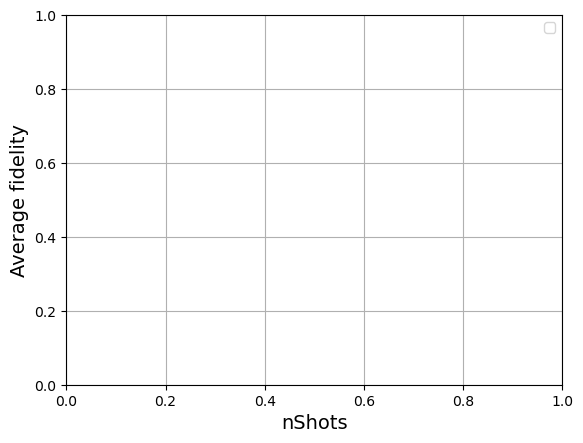

In [6]:
b = b/np.linalg.norm(b) # required to be of unit magnitude
print("b:", b)
fig, ax = plt.subplots()

mValues = [] #[2, 3, 5]
lineType = ['-','--',':','-.']
expt = 0
shots = [] #[10,25,50,100,500,1000]
for m in mValues:
	fidelityResult= []
	print("m: ",m)
	for nShots in shots:
		print("nShots: ",nShots)
		fAverage = 0
		HHL = myHHL(A,b,lambdaUpper = lambdaUpper, m = m, nShots = nShots)# type: ignore
		HHL.solveuExact()
		nSuccessfulTrials = 0
		nTrials = 25
		for t in range(nTrials):
			if (not HHL.executeHHL()):
				continue
			nSuccessfulTrials = nSuccessfulTrials +1
			fidelity = np.dot(HHL.uHHL,HHL.uExact)
			fAverage = fAverage + fidelity
		fAverage = fAverage/nSuccessfulTrials
		print("fAverage:", fAverage)
		fidelityResult.append(fAverage)
	
	plt.semilogx(shots, fidelityResult,lineType[expt])
	expt = expt +1

plt.legend(['m=2','m=3','m=5'])
plt.grid(visible = True)
plt.xlabel("nShots", fontsize = 14)
plt.ylabel("Average fidelity", fontsize = 14)


## fidelity versus P0

b: [0.70710678 0.70710678]


Text(0, 0.5, 'Average fidelity')

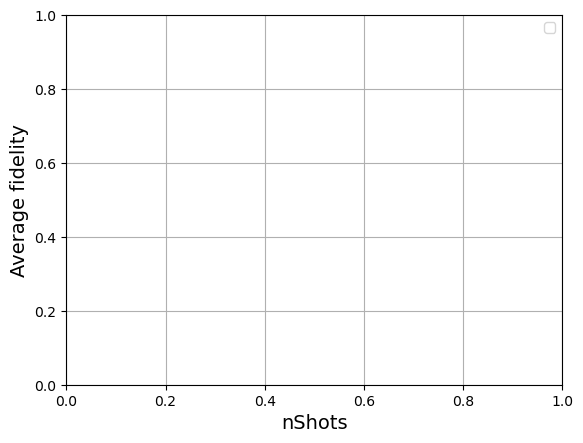

In [7]:
b = b/np.linalg.norm(b) # required to be of unit magnitude
print("b:", b)
fig, ax = plt.subplots()
pValues = [] # [0,0.05,0.1,0.15,0.2,0.25]
mValues = [] # [2, 3, 5]
lineType = ['-','--',':','-.']
expt = 0
nShots  = 1000
for m in mValues:
	fidelityResult= []
	print("m: ",m)
	for P0 in pValues:
		print("P0: ",P0)
		fAverage = 0
		HHL = myHHL(A,b,lambdaUpper = lambdaUpper, m = m,P0 = P0, nShots = nShots)# type: ignore
		HHL.solveuExact()
		nSuccessfulTrials = 0
		nTrials = 25
		for t in range(nTrials):
			if (not HHL.executeHHL()):
				continue
			nSuccessfulTrials = nSuccessfulTrials +1
			fidelity = np.dot(HHL.uHHL,HHL.uExact)
			fAverage = fAverage + fidelity
		fAverage = fAverage/nSuccessfulTrials
		print("fAverage:", fAverage)
		fidelityResult.append(fAverage)
	
	plt.semilogx(shots, fidelityResult,lineType[expt])
	expt = expt +1

plt.legend(['m=2','m=3','m=5'])
plt.grid(visible = True)
plt.xlabel("nShots", fontsize = 14)
plt.ylabel("Average fidelity", fontsize = 14)

## fidelity versus parameter p

b: [0.70710678 0.70710678]
m:  1
p:  0.25
λ_lower (Gershgorin): 0.250000
λ_lower (QPE): 0.990000
λ_lower (used): 0.990000
λ_lower (Gershgorin): 0.250000
λ_lower (QPE): 0.990000
λ_lower (used): 0.990000
λ_lower (Gershgorin): 0.250000
λ_lower (QPE): 0.990000
λ_lower (used): 0.990000
λ_lower (Gershgorin): 0.250000
λ_lower (QPE): 0.990000
λ_lower (used): 0.990000
λ_lower (Gershgorin): 0.250000
λ_lower (QPE): 0.990000
λ_lower (used): 0.990000
λ_lower (Gershgorin): 0.250000
λ_lower (QPE): 0.990000
λ_lower (used): 0.990000
λ_lower (Gershgorin): 0.250000
λ_lower (QPE): 0.990000
λ_lower (used): 0.990000
λ_lower (Gershgorin): 0.250000
λ_lower (QPE): 0.990000
λ_lower (used): 0.990000
λ_lower (Gershgorin): 0.250000
λ_lower (QPE): 0.990000
λ_lower (used): 0.990000
λ_lower (Gershgorin): 0.250000
λ_lower (QPE): 0.990000
λ_lower (used): 0.990000
λ_lower (Gershgorin): 0.250000
λ_lower (QPE): 0.990000
λ_lower (used): 0.990000
λ_lower (Gershgorin): 0.250000
λ_lower (QPE): 0.990000
λ_lower (used): 0.99000

KeyboardInterrupt: 

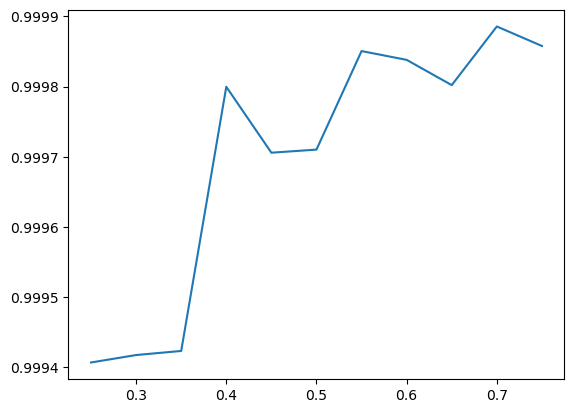

In [8]:
b = b/np.linalg.norm(b) # required to be of unit magnitude
print("b:", b)
fig, ax = plt.subplots()
pValues = [0,0.05,0.1,0.15,0.2,0.25]

mValues = [1,2,3]
lineType = ['-','--',':','-.']
expt = 0
nShots  = 1000
pRange = np.linspace(0.25,0.75,11)
for m in mValues:
	fidelityResult= []
	print("m: ",m)
	for p in pRange:
		print("p: ",p)
		fAverage = 0
		A = np.array([[1/2,p-1/2],[p-1/2,1/2]])
		HHL = myHHL(A,b,lambdaUpper = lambdaUpper, m = m, nShots = nShots)# type: ignore
		HHL.solveuExact()
		nSuccessfulTrials = 0
		nTrials = 25
		for t in range(nTrials):
			if (not HHL.executeHHL()):
				continue
			nSuccessfulTrials = nSuccessfulTrials +1
			fidelity = np.dot(HHL.uHHL,HHL.uExact)
			fAverage = fAverage + fidelity
		fAverage = fAverage/nSuccessfulTrials
		print("fAverage:", fAverage)
		fidelityResult.append(fAverage)
	
	plt.plot(pRange, fidelityResult,lineType[expt])
	expt = expt +1

plt.legend(['m=1','m=2','m=3'])
plt.grid(visible = True)
plt.xlabel("p", fontsize = 14);
plt.ylabel("Average fidelity", fontsize = 14);
